In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from sklearn.ensemble import IsolationForest
from scipy.spatial.distance import cdist

np.random.seed(42)

print("Libraries Loaded")

Libraries Loaded


In [ ]:
# Change dataset path here

#
file_path = "/content/drive/MyDrive/Colab Notebooks/FRS-FCM/heart.csv"
#file_path = "/content/drive/MyDrive/Colab Notebooks/dataset1/Amazon.csv"
#file_path = "/content/drive/MyDrive/Colab Notebooks/dataset1/Kolkata_Big_Pollution_Dataset_25000.csv"
#file_path = "/content/drive/MyDrive/Colab Notebooks/dataset/OnlineNewsPopularity.csv"
#file_path = "/content/drive/MyDrive/Colab Notebooks/dataset/car_evaluation.csv"
#file_path = "/content/drive/MyDrive/Colab Notebooks/dataset/food_ordering_behavior_dataset.csv"
#file_path = "/content/drive/MyDrive/Colab Notebooks/dataset/bestsellers with categories.csv"
#file_path = "/content/drive/MyDrive/Colab Notebooks/heart_failure_clinical_records_dataset.csv"
#file_path = "/content/drive/MyDrive/Colab Notebooks/DATASET/fashion-mnist_test.csv"

df = pd.read_csv(file_path)

print("Dataset Shape :", df.shape)

Dataset Shape : (1025, 14)


In [ ]:
# ------------------------------------------------------------
# Handle categorical values
# ------------------------------------------------------------

for col in df.columns:

    if df[col].dtype == "object":

        try:
            df[col] = pd.to_datetime(df[col])
            df[col] = df[col].map(lambda x: x.timestamp())

        except:
            df[col] = LabelEncoder().fit_transform(
                df[col].astype(str)
            )

# ------------------------------------------------------------
# Remove missing values
# ------------------------------------------------------------

df = df.fillna(df.mean(numeric_only=True))

# ------------------------------------------------------------
# Feature matrix
# ------------------------------------------------------------

X = df.values

# ------------------------------------------------------------
# Standardization
# ------------------------------------------------------------

scaler = StandardScaler()

X = scaler.fit_transform(X)

print("Preprocessing Completed")
print("Processed Shape :", X.shape)

Preprocessing Completed
Processed Shape : (1025, 14)


In [ ]:
iso = IsolationForest(
    contamination=0.03,
    random_state=42
)

mask = iso.fit_predict(X)

X = X[mask == 1]

print("Noise Removal Completed")
print("Filtered Shape :", X.shape)

Noise Removal Completed
Filtered Shape : (994, 14)


In [ ]:
feature_weights = np.var(X, axis=0)

feature_weights = (
    feature_weights /
    np.sum(feature_weights)
)

X = X * feature_weights

print("Feature Weighting Applied")

Feature Weighting Applied


In [ ]:
def initialize_U(n, c):

    return np.random.dirichlet(
        np.ones(c),
        size=n
    ).T


def compute_centers(X, U, m):

    um = U ** m

    centers = (
        um @ X
    ) / (
        np.sum(um, axis=1, keepdims=True) + 1e-8
    )

    return centers


def compute_distance(X, centers):

    return np.linalg.norm(
        X[None, :, :] - centers[:, None, :],
        axis=2
    ) + 1e-8


def update_U(dist, m):

    power = 2 / (m - 1)

    inv = dist ** (-power)

    return inv / np.sum(
        inv,
        axis=0,
        keepdims=True
    )

print("Core Functions Ready")

Core Functions Ready


In [ ]:
def run_fcm(X, c=3, m=2, max_iter=100):

    n = X.shape[0]

    U = initialize_U(n, c)

    for _ in range(max_iter):

        U_old = U.copy()

        centers = compute_centers(X, U, m)

        dist = compute_distance(X, centers)

        U = update_U(dist, m)

        if np.linalg.norm(U - U_old) < 1e-5:
            break

    labels = np.argmax(U, axis=0)

    return centers, U, labels

print("Traditional FCM Ready")

Traditional FCM Ready


In [ ]:
def compute_confidence(U):

    s = np.sort(U, axis=0)

    conf = (
        s[-1] - s[-2]
    ) / (
        s[-1] + 1e-8
    )

    return conf


def adaptive_threshold(conf):

    theta = np.percentile(conf, 20)

    return theta


def boundary_refinement(
    X,
    U,
    c,
    max_iter=50
):

    conf = compute_confidence(U)

    theta = adaptive_threshold(conf)

    labels = np.argmax(U, axis=0)

    boundary_idx = np.where(
        conf < theta
    )[0]

    if len(boundary_idx) < 5:

        return labels, theta, len(boundary_idx)

    Xb = X[boundary_idx]

    weights = 1 - conf[boundary_idx]

    Ub = initialize_U(
        len(Xb),
        c
    )

    old_centers = compute_centers(
        Xb,
        Ub,
        m=2
    )

    for _ in range(max_iter):

        Ub_old = Ub.copy()

        um = (
            (Ub ** 2.5) * weights
        )

        centers_b = (
            um @ Xb
        ) / (
            np.sum(
                um,
                axis=1,
                keepdims=True
            ) + 1e-8
        )

        dist_b = compute_distance(
            Xb,
            centers_b
        )

        Ub = update_U(
            dist_b,
            m=2.5
        )

        if np.linalg.norm(Ub - Ub_old) < 1e-5:
            break

    refined_labels = np.argmax(
        Ub,
        axis=0
    )

    old_dist = np.mean(
        np.min(
            compute_distance(
                Xb,
                old_centers
            ),
            axis=0
        )
    )

    new_dist = np.mean(
        np.min(
            compute_distance(
                Xb,
                centers_b
            ),
            axis=0
        )
    )

    if new_dist < old_dist:

        labels[boundary_idx] = refined_labels

    return labels, theta, len(boundary_idx)

print("Proposed FRS-FCM Ready")

Proposed FRS-FCM Ready


In [ ]:
# ------------------------------------------------------------
# Traditional FCM
# ------------------------------------------------------------

centers_fcm, U_fcm, fcm_labels = run_fcm(
    X,
    c=3
)

# ------------------------------------------------------------
# Proposed FRS-FCM
# ------------------------------------------------------------

centers_frs, U_frs, _ = run_fcm(
    X,
    c=3
)

frs_labels, theta, bcount = boundary_refinement(
    X,
    U_frs,
    c=3
)

print("Clustering Completed")

print("\nBoundary Points :", bcount)

print("Threshold :", round(theta, 4))

Clustering Completed

Boundary Points : 197
Threshold : 0.0038


In [ ]:
results = {

    "FCM": [

        silhouette_score(X, fcm_labels),

        davies_bouldin_score(X, fcm_labels),

        calinski_harabasz_score(X, fcm_labels),

        np.mean(
            np.min(
                cdist(X, centers_fcm),
                axis=1
            )
        ),

        np.var(fcm_labels)
    ],

    "FRS-FCM": [

        silhouette_score(X, frs_labels),

        davies_bouldin_score(X, frs_labels),

        calinski_harabasz_score(X, frs_labels),

        np.mean(
            np.min(
                cdist(X, centers_frs),
                axis=1
            )
        ),

        np.var(frs_labels)
    ]
}

metrics = [

    "Silhouette",

    "DB Index",

    "CH Score",

    "Compactness",

    "Cluster Spread"
]

result_df = pd.DataFrame(
    results,
    index=metrics
).round(4)

display(
    result_df.style
    .background_gradient(cmap="coolwarm")
    .set_caption(
        "Clustering Performance Comparison"
    )
)

,FCM,FRS-FCM
Silhouette,0.046400,0.179800
DB Index,2.213000,2.057000
CH Score,113.331300,222.329500
Compactness,0.256000,0.256900
Cluster Spread,0.259800,0.248800


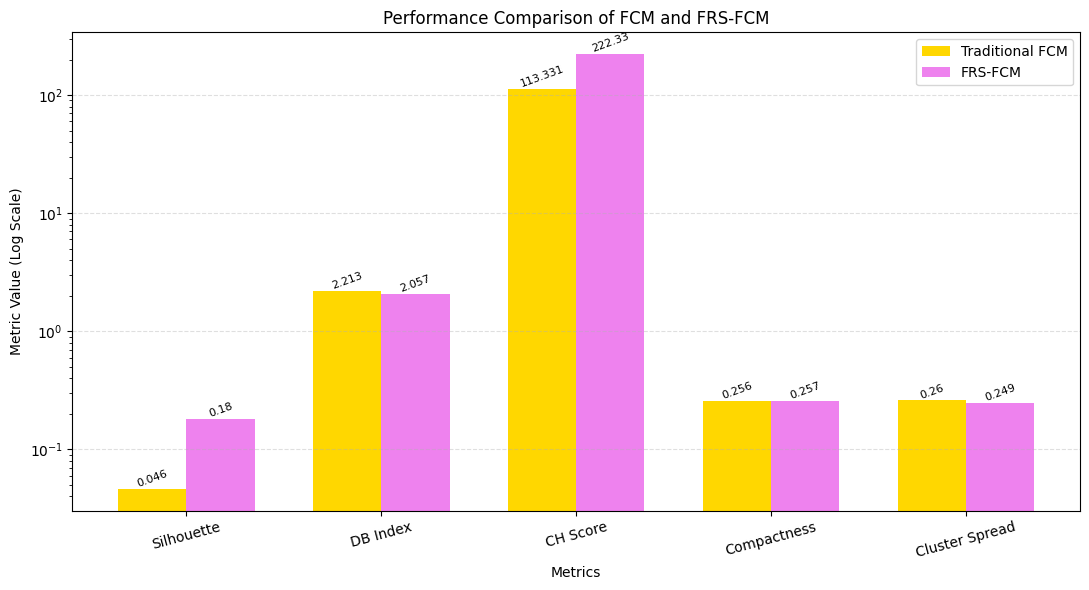

In [ ]:
# ============================================================
# BAR GRAPH COMPARISON WITH LOG SCALE Y-AXIS
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Metric Names
# ------------------------------------------------------------

metrics = [
    "Silhouette",
    "DB Index",
    "CH Score",
    "Compactness",
    "Cluster Spread"
]

# ------------------------------------------------------------
# Metric Values
# ------------------------------------------------------------

fcm_values = result_df["FCM"].values
frs_values = result_df["FRS-FCM"].values

# ------------------------------------------------------------
# Bar Positions
# ------------------------------------------------------------

x = np.arange(len(metrics))

width = 0.35

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

plt.figure(figsize=(11,6))

# ------------------------------------------------------------
# FCM Bars
# ------------------------------------------------------------

plt.bar(
    x - width/2,
    fcm_values,
    width,
    label="Traditional FCM",
    color="gold"
)

# ------------------------------------------------------------
# FRS-FCM Bars
# ------------------------------------------------------------

plt.bar(
    x + width/2,
    frs_values,
    width,
    label="FRS-FCM",
    color="violet"
)

# ------------------------------------------------------------
# LOG SCALE FOR Y-AXIS
# ------------------------------------------------------------

plt.yscale("log")

# ------------------------------------------------------------
# Labels and Title
# ------------------------------------------------------------

plt.xticks(
    x,
    metrics,
    rotation=15
)

plt.ylabel("Metric Value (Log Scale)")

plt.xlabel("Metrics")

plt.title(
    "Performance Comparison of FCM and FRS-FCM"
)

plt.legend()

# ------------------------------------------------------------
# Value Labels
# ------------------------------------------------------------

for i, v in enumerate(fcm_values):

    plt.text(
        i - width/2,
        v,
        str(round(v, 3)),
        ha='center',
        va='bottom',
        fontsize=8,
        rotation=20
    )

for i, v in enumerate(frs_values):

    plt.text(
        i + width/2,
        v,
        str(round(v, 3)),
        ha='center',
        va='bottom',
        fontsize=8,
        rotation=20
    )

# ------------------------------------------------------------
# Grid
# ------------------------------------------------------------

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

# ------------------------------------------------------------
# Tight Layout
# ------------------------------------------------------------

plt.tight_layout()

# ------------------------------------------------------------
# Show Graph
# ------------------------------------------------------------

plt.show()

In [ ]:
fcm_score = 0
frs_score = 0

# Higher better
if result_df.loc["Silhouette", "FRS-FCM"] > result_df.loc["Silhouette", "FCM"]:
    frs_score += 1
else:
    fcm_score += 1

if result_df.loc["CH Score", "FRS-FCM"] > result_df.loc["CH Score", "FCM"]:
    frs_score += 1
else:
    fcm_score += 1

# Lower better
if result_df.loc["DB Index", "FRS-FCM"] < result_df.loc["DB Index", "FCM"]:
    frs_score += 1
else:
    fcm_score += 1

if result_df.loc["Compactness", "FRS-FCM"] < result_df.loc["Compactness", "FCM"]:
    frs_score += 1
else:
    fcm_score += 1

# Higher better
if result_df.loc["Cluster Spread", "FRS-FCM"] > result_df.loc["Cluster Spread", "FCM"]:
    frs_score += 1
else:
    fcm_score += 1

print("Final Conclusion\n")

if frs_score > fcm_score:

    print("FRS-FCM performs better on this dataset")

    print(
        "Boundary refinement improves overlap handling and uncertainty modeling"
    )

elif fcm_score > frs_score:

    print("Traditional FCM performs better on this dataset")

    print(
        "Dataset may contain well-separated clusters with low uncertainty"
    )

else:

    print("Both methods show comparable performance")

Final Conclusion

FRS-FCM performs better on this dataset
Boundary refinement improves overlap handling and uncertainty modeling


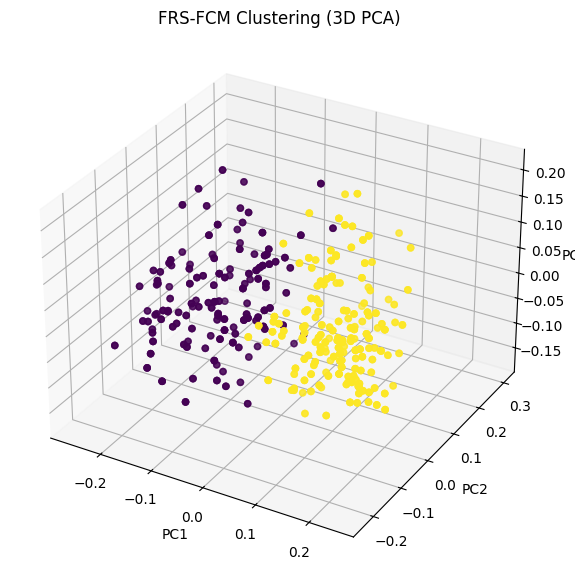

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

pca = PCA(n_components=3)

X_3d = pca.fit_transform(X)

fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(
    111,
    projection='3d'
)

ax.scatter(
    X_3d[:, 0],
    X_3d[:, 1],
    X_3d[:, 2],
    c=frs_labels
)

ax.set_title(
    "FRS-FCM Clustering (3D PCA)"
)

ax.set_xlabel("PC1")

ax.set_ylabel("PC2")

ax.set_zlabel("PC3")

plt.show()

T Statistic = 1.0
Critical Value = 2.776
P Value = 0.37406


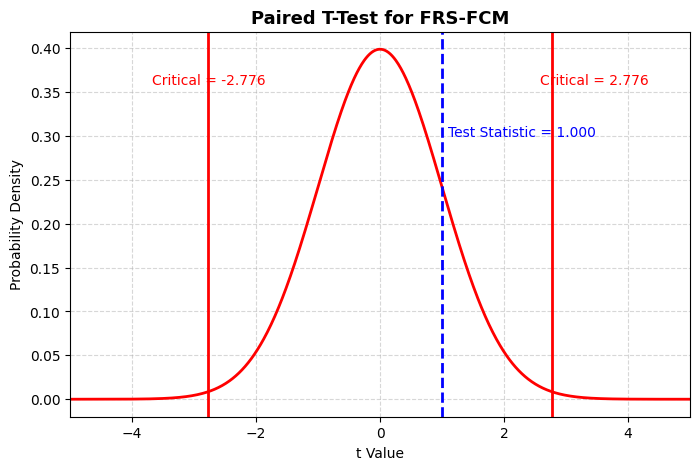

In [ ]:
# ============================================================
# PAIRED T-TEST USING YOUR RESULT DATAFRAME
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import ttest_rel
from scipy.stats import t
from scipy.stats import norm

# ------------------------------------------------------------
# Extract Metric Values from result_df
# ------------------------------------------------------------

fcm_values = result_df["FCM"].values

frsfcm_values = result_df["FRS-FCM"].values

# ------------------------------------------------------------
# Paired t-test
# ------------------------------------------------------------

t_statistic, p_value = ttest_rel(
    frsfcm_values,
    fcm_values
)

# ------------------------------------------------------------
# Critical Value
# ------------------------------------------------------------

alpha = 0.05

df = len(fcm_values) - 1

critical_value = t.ppf(
    1 - alpha/2,
    df
)

print("T Statistic =", round(t_statistic, 3))
print("Critical Value =", round(critical_value, 3))
print("P Value =", round(p_value, 5))

# ------------------------------------------------------------
# Distribution Curve
# ------------------------------------------------------------

x = np.linspace(-5, 5, 1000)

y = norm.pdf(x, 0, 1)

# ------------------------------------------------------------
# Plot Graph
# ------------------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    x,
    y,
    color='red',
    linewidth=2
)

# Critical lines
plt.axvline(
    -critical_value,
    color='red',
    linewidth=2
)

plt.axvline(
    critical_value,
    color='red',
    linewidth=2
)

# Test statistic line
plt.axvline(
    t_statistic,
    color='blue',
    linestyle='--',
    linewidth=2
)

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

plt.text(
    -critical_value - 0.9,
    max(y)*0.9,
    f'Critical = {-critical_value:.3f}',
    color='red',
    fontsize=10
)

plt.text(
    critical_value - 0.2,
    max(y)*0.9,
    f'Critical = {critical_value:.3f}',
    color='red',
    fontsize=10
)

plt.text(
    t_statistic + 0.1,
    max(y)*0.75,
    f'Test Statistic = {t_statistic:.3f}',
    color='blue',
    fontsize=10
)

# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

plt.title(
    'Paired T-Test for FRS-FCM',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('t Value')
plt.ylabel('Probability Density')

plt.grid(True, linestyle='--', alpha=0.5)

plt.xlim(-5, 5)

plt.show()